# Day 14: The 1-Sample $t$-Test

In this notebook, we will learn:

- How to conduct a 1-sample t-test
- How to interpret the results and report them so that others can understand them
- How to find a confidence interval for the mean of a population
- How the confidence interval itself can be interpretted instead of running a t-test


In [6]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
from scipy.stats import t
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde

In [7]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, "", min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data), stats.iqr(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat), stats.iqr(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return 

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

def density(data, num = None):
  if isinstance(data, Table):
    sns.kdeplot( data = data.column(num), bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  else:
    if num == None:
      num = 'Variable'  ;  sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
    else:
      sns.kdeplot( data = data, bw_method="scott", bw_adjust=0.75, cut=3 )  ;  plots.title(f'Density Plot of {num}')  ;  plots.show()
  return

def densities(tab, var, group_var):
  groups = tab.column(group_var) ;  unique_groups = np.unique(groups)  ;  plots.figure()
  for g in unique_groups:
    # Filter data for the current group
    mask = (groups == g)
    x = tab.column(var)[mask]   
    # Calculate KDE for the group subset
    kde = gaussian_kde(x)
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 512)  ;    plots.plot(x_grid, kde(x_grid), label=str(g))   
  plots.title(f'Density Plot of {var} by {group_var}')  ;  plots.xlabel(f'{var}')  ;  plots.ylabel('Density')
  plots.legend()  ;  plots.show()
  return

# T-Distribution #

The t-distribution is a probability distribution, like the standard normal distribution that we learned about before, but it has an extra parameter, the *degrees of freedom*.  The degrees of freedom affect the shape of the distribution:

![T-dist with Normal](TwNormal2.gif)

As you can see from the gif above, when the degrees of freedom (df) are low, the tails of the distribution are thicker and the hump in the middle is shorter. The <span style="color:red;font-weight:bold">red curve</span> shown is the **standard normal distribution**.  As the degrees of freedom (*df*) increase, the $t$-distribution converges to the standard normal. The *df* track closely with sample size.

This $t$-distribution is the probability distribution used to compute the $p$-values whenever we do any type of t-test. 

### Data Checks for $t$-Tests

<table style="width:75%">
  <tr>
    <th>Description</th>
    <th>Sample Size</th> 
    <th>Data Checks</th> 
    <th>Graphics</th>
    
  </tr>
  <tr>
    <td style="text-align: center; vertical-align: middle;">Tiny</td>
    <td style="text-align: center; vertical-align: middle;">$n\leq 15$</td>
    <td style="text-align: center; vertical-align: middle;">We need evidence the sample was drawn from a <span style="font-weight:bold">bell-shaped</span> distribution, and <span style="font-weight:bold">no outliers</spac>.</td>
    <td style="text-align: center; vertical-align: middle;">Check histogram or density plot (bell-shape), and check box plot (no outliers).</td>
  </tr>
  <tr>
    <td style="text-align: center; vertical-align: middle;">Small</td>
    <td style="text-align: center; vertical-align: middle;">$15<n < 40$</td>
    <td style="text-align: center; vertical-align: middle;">We <span style="font-weight:bold">prefer</span> evidence the sample was drawn from a bell-shaped distribution, and limited (or balanced) outliers.</td>
    <td style="text-align: center; vertical-align: middle;">Check histogram or density plot (bell-shape preferred), check box plot (limited outliers)</td>
  </tr>
  <tr>
    <td style="text-align: center; vertical-align: middle;">Large</td>
    <td style="text-align: center; vertical-align: middle;">$n\geq 40$</td>
    <td style="text-align: center; vertical-align: middle;">We prefer evidence the sample was drawn from a bell-shaped distribution and note that massive outliers and skew may erode the accuracy of results (p-values).</td>
    <td style="text-align: center; vertical-align: middle;">No data checks required due to the <span style="font-weight:bold">robustness of the t-statistic</span>.</td>
  </tr>
</table>

## Examples of Real-World Questions We Can Answer ##

### Rearch Questions ###

1. Do students take 5 classes per semester on average?
 
2. Students get at least 8 hours of sleep per night?

3. Do babies born to women who do not smoke weigh more than 115 oz on average?

Throughout this notebook, let's set $\alpha  = 0.05$.  So we'll consider a $p$-value to be small if $p < 0.05$.  

In [8]:
classes = Table.read_table('ClassData.csv')
classes

CollegeYear,SleepHours,FavSport,NumCourses,ComputerType,LunchAmt
Second,8,Basketball,6,Mac,11
Second,7,Tennis,5,Mac,10
Second,8,Soccer,5,Mac,10
First,9,Basketball,5,Mac,4
Second,4,Basketball,6,PC,0
Third,7,nan,4,PC,11
Second,7,Basketball,5,Mac,7
First,7,Basketball,6,PC,0
Third,8.5,Basketball,4,Mac,10
Third,7,Basketball,6,PC,7


## Example 1: Fifteen to Finish
To complete a Bachelors in 4 years (without summers), a student must average 15 credit hours per semester.  Most classes are 3 credit hours, so this is an average of 5 classes a semester. Given the above data in the **classes** table, determine the following:

**Research Question:** On average do students take 5 classes per semester?

### HypotheseS

### Data Checks

### Run the Test

### Reporting Out

# What is this test doing? #

## Step 1: Determine the null and alternative hypotheses 

The null hypothesis for a 1-sample t-test is typically:

$H_o: \mu = \mu_o$

And the alternative is one of these:

$H_a: Pick\ one\   \left\{ \begin{array}{l} \mu \not= \mu_o \\ \mu < \mu_o \\ \mu > \mu_o \end{array} \right.$


So in this case it's $H_o: \mu = 5$ and $H_a: \mu \not= 5$.

## Step 2: Compute test statistic (t)

Now that we know the null hypothesis, we can compute (or have Python compute) the test statistic $t$. In this case, we have the following:

$$  t = \frac{ \overline{x} -\mu_o}{\frac{S_x}{\sqrt{n}}}$$

## Step 3: Degrees of freedom

For a 1-sample t-test the degrees of freedom are $$df = n - 1$$ 

Once the degrees of freedom are known, the correct $t$-distribution graph can be used to find the $p$-value.  

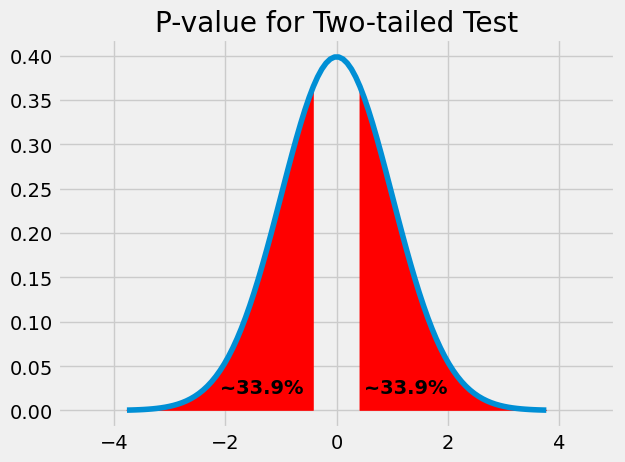

In [9]:
rv = t(df=297, loc=0, scale=1) ; x = np.linspace(rv.ppf(0.0001), rv.ppf(0.9999), 100) ; y = rv.pdf(x) 

plots.xlim(-5,5) ; plots.plot(x,y) ; plots.fill_between(x, y, where = abs(x) > 0.4146, color="r")
plots.title("P-value for Two-tailed Test")
plots.text(.5, .02, "~33.9%", color="black", weight="bold", size="medium")
plots.text(-2.1, .02, "~33.9%", color="black", weight="bold", size="medium");

## Step 4: Computing the p-value

In this example, the test statistic was $t \approx 0.414$.  And we're using the so-called two-tailed alternative, the one with $\not=$ in it.  

So we mark the point with $x = 0.414$ **and** the point $x = -0.414$ on the x-axis, and we find the shaded region *outside* of those spots but under the curve.  This is the p-value.  

Recall this was the output:

**Ttest_1sampResult(statistic=0.4146500929078039, pvalue=0.6786974101872751)**

#### Reporting out:  ####

##### The mean of this sample is 5.017 classes (per student per semester).  This is not statistically significant (t = 0.414, p = 0.679), therefore this not evidence that the mean number of classes a student takes per semester is anything other than 5 . #####

## Example 2: Sleep

**Research Question:** Given the above data in the **classes** table, determine if students get at least 8 hours of sleep per night?

### Hypotheses

### Data Checks

### Run the Test

### Reporting Out

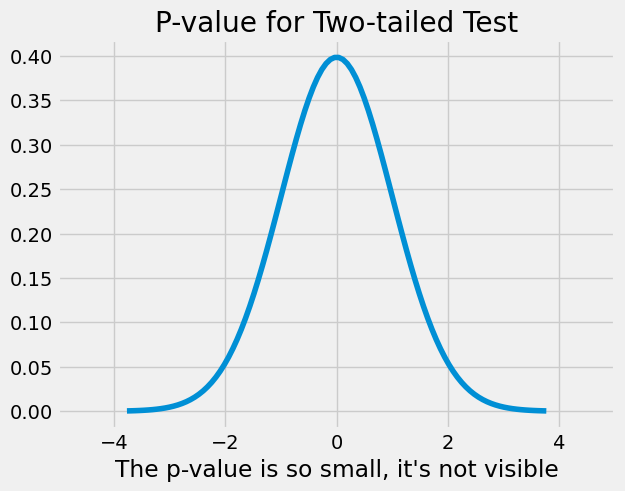

In [17]:
rv = t(df=297, loc=0, scale=1) ; x = np.linspace(rv.ppf(0.0001), rv.ppf(0.9999), 100) ; y = rv.pdf(x) 

plots.xlim(-5,5) ; plots.plot(x,y) ; plots.fill_between(x, y, where = abs(x) > 8.3, color="r")
plots.title("P-value for Two-tailed Test") ; plots.xlabel("The p-value is so small, it's not visible");

## Example 3: Birth Weight and Smoking

**Research Question:** Given the databelow in the **births** table, determine whether babies born to mothers that don't smoke tend to weigh more than 118 ounces?

In [18]:
births =Table.read_table("baby.csv")
nonsmokers = births.where('Maternal Smoker', False)
nonsmokers = nonsmokers.take(np.arange(1,700,20))
births.show(5)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False


### Hypotheses

### Data Checks

### Run the Test

### Reporting Out